In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             confusion_matrix, roc_auc_score,
                             classification_report)

# Pull 2 years of HSBC data
hsbc = yf.download("HSBA.L", period="2y", auto_adjust=True)

df = pd.DataFrame()
df['price'] = hsbc['Close'].values.flatten()
df['volume'] = hsbc['Volume'].values.flatten()
df.index = hsbc.index

print("Shape:", df.shape)
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Shape: (507, 2)
                  price    volume
Date                             
2026-03-16  1195.800049  16539898
2026-03-17  1207.199951  18852466
2026-03-18  1209.199951  23027117
2026-03-19  1171.599976  37288494
2026-03-20  1144.199951  84775948


In [2]:
# Daily return
df['return'] = df['price'].pct_change() * 100

# TARGET — direction: 1 = up, 0 = down
df['direction'] = (df['return'] > 0).astype(int)

# Previous returns
df['prev_return_1'] = df['return'].shift(1)
df['prev_return_2'] = df['return'].shift(2)
df['prev_return_3'] = df['return'].shift(3)

# Moving averages
df['ma_5'] = df['price'].rolling(window=5).mean()
df['ma_20'] = df['price'].rolling(window=20).mean()

# Price vs moving average — shifted to avoid leakage
df['price_vs_ma5'] = ((df['price'] - df['ma_5']) / df['ma_5'] * 100).shift(1)
df['price_vs_ma20'] = ((df['price'] - df['ma_20']) / df['ma_20'] * 100).shift(1)
df['ma_crossover'] = (df['ma_5'] - df['ma_20']).shift(1)

# Volatility — shifted
df['volatility_10'] = df['return'].rolling(window=10).std().shift(1)
df['volatility_20'] = df['return'].rolling(window=20).std().shift(1)

# Volume — shifted
df['volume_change'] = df['volume'].pct_change().shift(1) * 100
df['volume_vs_avg'] = (df['volume'] / df['volume'].rolling(window=20).mean()).shift(1)

df = df.dropna()

# Check class balance
up_days = df['direction'].sum()
down_days = len(df) - up_days
print(f"Up days:   {up_days} ({round(up_days/len(df)*100, 1)}%)")
print(f"Down days: {down_days} ({round(down_days/len(df)*100, 1)}%)")
print(f"\nTotal trading days: {len(df)}")

Up days:   296 (60.9%)
Down days: 190 (39.1%)

Total trading days: 486


In [3]:
features = [
    'prev_return_1', 'prev_return_2', 'prev_return_3',
    'price_vs_ma5', 'price_vs_ma20', 'ma_crossover',
    'volatility_10', 'volatility_20',
    'volume_change', 'volume_vs_avg'
]

X = df[features]
y = df['direction']

# Split — no shuffle, time order respected
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"Baseline accuracy to beat: 60.9%")

# Model 1 — Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model 2 — Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Accuracy Comparison ===")
print(f"Baseline (always predict up): 60.9%")
print(f"Logistic Regression:          {round(accuracy_score(y_test, y_pred_lr)*100, 2)}%")
print(f"Random Forest:                {round(accuracy_score(y_test, y_pred_rf)*100, 2)}%")

Training samples: 388
Test samples:     98
Baseline accuracy to beat: 60.9%

=== Accuracy Comparison ===
Baseline (always predict up): 60.9%
Logistic Regression:          61.22%
Random Forest:                59.18%


In [4]:
print("=" * 55)
print("LOGISTIC REGRESSION — DETAILED METRICS")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, 
      target_names=['Down', 'Up']))

print("=" * 55)
print("RANDOM FOREST — DETAILED METRICS")
print("=" * 55)
print(classification_report(y_test, y_pred_rf,
      target_names=['Down', 'Up']))

# ROC-AUC scores
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("=" * 55)
print("ROC-AUC SCORES")
print("=" * 55)
print(f"Random guess baseline:  0.5000")
print(f"Logistic Regression:    {round(auc_lr, 4)}")
print(f"Random Forest:          {round(auc_rf, 4)}")

LOGISTIC REGRESSION — DETAILED METRICS
              precision    recall  f1-score   support

        Down       0.50      0.24      0.32        38
          Up       0.64      0.85      0.73        60

    accuracy                           0.61        98
   macro avg       0.57      0.54      0.53        98
weighted avg       0.58      0.61      0.57        98

RANDOM FOREST — DETAILED METRICS
              precision    recall  f1-score   support

        Down       0.38      0.08      0.13        38
          Up       0.61      0.92      0.73        60

    accuracy                           0.59        98
   macro avg       0.49      0.50      0.43        98
weighted avg       0.52      0.59      0.50        98

ROC-AUC SCORES
Random guess baseline:  0.5000
Logistic Regression:    0.5482
Random Forest:          0.5961


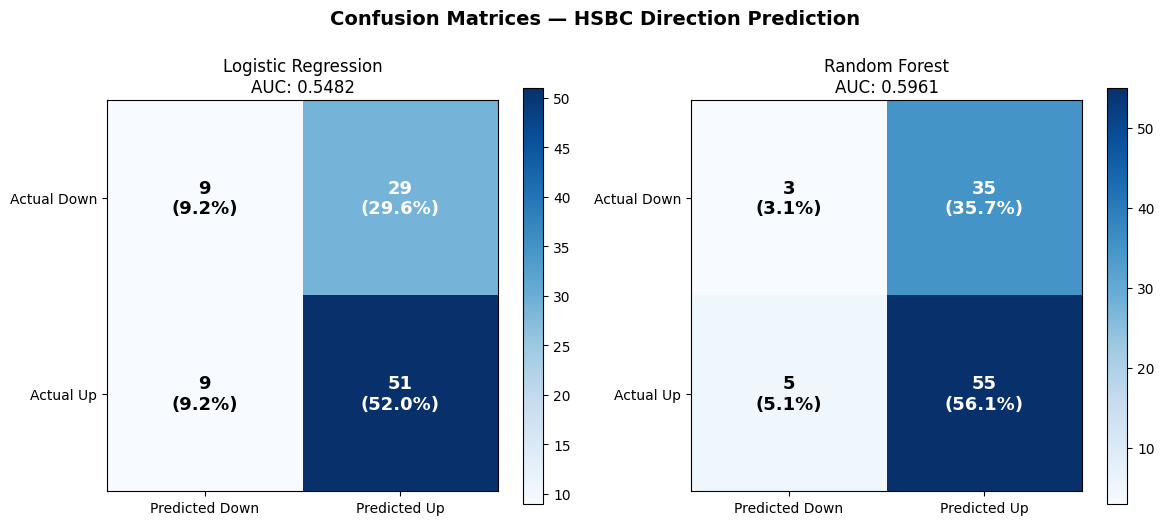

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Down', 'Predicted Up'])
    ax.set_yticklabels(['Actual Down', 'Actual Up'])
    
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > cm.max()/2 else 'black'
            ax.text(j, i, f'{cm[i,j]}\n({round(cm[i,j]/len(y_true)*100, 1)}%)',
                   ha='center', va='center', 
                   fontsize=13, fontweight='bold', color=color)
    
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plot_confusion(ax1, y_test, y_pred_lr, 
               f'Logistic Regression\nAUC: {round(auc_lr, 4)}')
plot_confusion(ax2, y_test, y_pred_rf,
               f'Random Forest\nAUC: {round(auc_rf, 4)}')

plt.suptitle('Confusion Matrices — HSBC Direction Prediction', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
print("=" * 55)
print("CLASSIFICATION EXPERIMENT — SUMMARY")
print("=" * 55)
print(f"""
PROBLEM
  Predict direction of HSBC daily return — up or down
  Binary classification: 1 = up, 0 = down
  
DATA
  486 trading days — 2 years of real LSE data
  Training: 388 days | Test: 98 days
  Class balance: 60.9% up, 39.1% down

RESULTS
  Model                 Accuracy   AUC     Down Recall
  Baseline (always up)  60.9%      0.50    0%
  Logistic Regression   61.22%     0.5482  24%
  Random Forest         59.18%     0.5961  8%

KEY FINDINGS
  1. Both models barely beat the baseline
     — price and volume features alone insufficient
     
  2. Both models biased toward up days
     — class imbalance causes systematic bias
     — models learn "always predict up" is safe
     
  3. Random Forest has better AUC despite lower accuracy
     — better at separating classes probabilistically
     — accuracy is misleading with imbalanced classes
     
  4. Down day prediction is very poor
     — most critical failure for risk management
     — need macro and sentiment features to improve

WHAT WOULD IMPROVE THIS MODEL
  — News sentiment (NLP on financial headlines)
  — Macro indicators (interest rates, inflation)
  — Sector-wide signals (FTSE 100 direction)
  — Class balancing techniques (SMOTE, class weights)
  — More sophisticated algorithms (XGBoost, LSTM)

INTERVIEW INSIGHT
  A model with 61% accuracy on stock direction
  that avoids down days well could be genuinely 
  profitable. The business value is not in accuracy
  alone — it's in precision on the signal you act on.
""")
print("=" * 55)

CLASSIFICATION EXPERIMENT — SUMMARY

PROBLEM
  Predict direction of HSBC daily return — up or down
  Binary classification: 1 = up, 0 = down

DATA
  486 trading days — 2 years of real LSE data
  Training: 388 days | Test: 98 days
  Class balance: 60.9% up, 39.1% down

RESULTS
  Model                 Accuracy   AUC     Down Recall
  Baseline (always up)  60.9%      0.50    0%
  Logistic Regression   61.22%     0.5482  24%
  Random Forest         59.18%     0.5961  8%

KEY FINDINGS
  1. Both models barely beat the baseline
     — price and volume features alone insufficient

  2. Both models biased toward up days
     — class imbalance causes systematic bias
     — models learn "always predict up" is safe

  3. Random Forest has better AUC despite lower accuracy
     — better at separating classes probabilistically
     — accuracy is misleading with imbalanced classes

  4. Down day prediction is very poor
     — most critical failure for risk management
     — need macro and sentiment f